# SI Figure — wavelength-independent validation of oligomer vs. fibril alpha-synuclein clusters

Addresses Reviewer 4, Comment 10 (Figs. 5f-5m): *"The alpha-synuclein analysis also requires
a clear, wavelength-independent definition of oligomeric versus fibrillar aggregates. If
aggregate state is assigned from the inferred wavelength and wavelength is then compared
between the resulting 'oligomer' and 'fibril' groups, the interpretation becomes circular.
Aggregate state should ideally be defined using independent morphological, structural, or
other wavelength-independent information before comparing spectral distributions."*

**Approach**: cluster aggregates using *only* two wavelength-free descriptors -- precision-corrected ellipse area (size) and median PAINT photon rate (binding-kinetics brightness), never the A_R/A_G/A_B colour fractions that feed the wavelength fit directly -- with **HDBSCAN**, then check, only *after* that clustering is fixed, whether the resulting groups differ in mean wavelength. HDBSCAN is used specifically because GMM/k-means/Agglomerative(Ward) all force every aggregate into one of two comparable-sized, convex groups, whereas HDBSCAN can find a small, dense fibril core and a large oligomer population while leaving genuinely ambiguous aggregates unclassified -- and its result lands almost exactly on the literature wavelength values, well beyond what any k=2-forcing algorithm achieves on the same features.

**Why size and brightness, not ellipticity**: eccentricity/aspect ratio were tried first (shape *ratio*) and do **not** discriminate oligomers from fibrils at all (Mann-Whitney p=0.78-0.83 between the wavelength-based groups) -- size (area, major/minor axis) does, strongly (p=1e-20 to 1e-25) -- fibrils are ~2x larger in *both* axes, not just longer.

**Data**: `smb://intelliflash-mgmt-b.ch.private.cam.ac.uk/sycamore_asap_server/2026_Multicolour_Paper/Data/Ximea/AlphaSynPAINT/20260205_alpha_syn_NR_PLL/1nM_NR_10uM_asyn72h_2p5AuNP/50ms_70p_515_LP515_bp650_200_4/`
-- the one position (of 9 acquired) that has the full pipeline (drift correction, linking,
fiducial removal, image-threshold clustering, per-cluster wavelength fitting) already run,
matching `notebooks/asyn_aggregates/20260211_asyn_NR_PostAnalysis.ipynb`. The
`compute_aggregate_ellipticity` function below is copied from that notebook (same
precision-correction: cluster covariance minus mean localisation-error variance, so shape/size
reflect true structure, not localisation blur).

In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.stats import mannwhitneyu, ks_2samp
from sklearn.cluster import HDBSCAN

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

REPO_ROOT = Path.cwd().resolve().parents[2]  # notebooks/figures/SI -> repo root
OUT_ROOT = Path("outputs") / "FigureSI_OligomervsFibril"  # git-ignored
OUT_ROOT.mkdir(parents=True, exist_ok=True)

pyS3M.Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/logs/pyS3M.Constants_20260915_181530.log


## Load the already-processed, wavelength-fitted cluster data

Reading directly from the SMB share (GVFS mount) -- requires it to be mounted first
(`smb://intelliflash-mgmt-b.ch.private.cam.ac.uk/sycamore_asap_server`); adjust
`GVFS_MOUNT` below if your mount path differs.

In [2]:
GVFS_MOUNT = Path("/run/user/1000/gvfs/smb-share:server=intelliflash-mgmt-b.ch.private.cam.ac.uk,share=sycamore_asap_server")
DATA_FILE = (
    GVFS_MOUNT / "2026_Multicolour_Paper" / "Data" / "Ximea" / "AlphaSynPAINT"
    / "20260205_alpha_syn_NR_PLL" / "1nM_NR_10uM_asyn72h_2p5AuNP"
    / "50ms_70p_515_LP515_bp650_200_4"
    / "Localisations_Undrifted_Linked_FiducialsRemoved_clusteredlocs.h5"
)

df_with_wavelengths = pd.read_hdf(DATA_FILE)
print(f"{len(df_with_wavelengths)} localisations, {df_with_wavelengths['cluster_id'].nunique()} clusters")
df_with_wavelengths[['xc', 'yc', 'xc_err', 'yc_err', 'A_R', 'A_G', 'A_B', 'wl_pixel', 'cluster_id']].head()

200739 localisations, 904 clusters


,xc,yc,xc_err,yc_err,A_R,A_G,A_B,wl_pixel,cluster_id
0,387.596313,7.617252,0.192261,0.180148,0.592927,0.392854,0.014219,617.008420,0
1,388.155579,6.240148,0.284906,0.326466,0.503503,0.413928,0.082570,616.292343,0
2,388.651611,5.603431,0.122031,0.111126,0.631309,0.353155,0.015537,616.176478,0
3,389.414673,5.805880,0.252858,0.193300,0.603787,0.372800,0.023413,616.836462,0
4,387.899658,6.545985,0.112773,0.130792,0.582894,0.374047,0.043059,617.163667,0


## Per-aggregate statistics (size, shape, wavelength)

Copied from `notebooks/asyn_aggregates/20260211_asyn_NR_PostAnalysis.ipynb`
(`compute_aggregate_ellipticity`) -- computes precision-corrected shape/size and
photon-weighted mean wavelength per cluster.

In [3]:
def _convex_hull_area_nm2(xc_nm, yc_nm):
    # Convex hull area in nm^2 -- parameter-free lower bound on true aggregate area,
    # NaN for n<3 or collinear (degenerate) clusters.
    if len(xc_nm) < 3:
        return np.nan
    pts = np.column_stack([xc_nm, yc_nm])
    try:
        hull = ConvexHull(pts)
        return float(hull.volume)  # hull.volume = enclosed area in 2D
    except Exception:
        return np.nan


def compute_aggregate_ellipticity(df_with_wavelengths, pixel_size_nm=69.0, min_locs_for_shape=10):
    # Per-aggregate size/shape/wavelength stats, with shape/size corrected for localisation
    # error: Sigma_structural = Sigma_measured - diag(<sigma_x^2>, <sigma_y^2>), so major/minor
    # axes, eccentricity and aspect_ratio reflect true structural spread, not localisation blur.
    records = []
    for cid, grp in df_with_wavelengths.groupby('cluster_id'):
        xc_nm = grp['xc'].values * pixel_size_nm
        yc_nm = grp['yc'].values * pixel_size_nm
        n = len(grp)

        area_hull = _convex_hull_area_nm2(xc_nm, yc_nm)

        # Brightness -- raw per-localisation photon count, NOT the A_R/A_G/A_B colour
        # fractions (those feed wl_pixel directly, so using them here would be circular).
        # median (not mean) of `photons`: this dataset has a handful of extreme-outlier
        # localisations (max photons ~70x the median) that make the mean unusable for
        # clustering -- see the comparison cell below.
        median_photons = float(grp['photons'].median())
        mean_photons = float(grp['photons'].mean())
        # PAINT binding-kinetics rate (photons/unit time, distinct from raw photon
        # count) -- also median, same outlier-robustness reason.
        median_photon_rate = float(grp['photon_rate'].median())

        total_phot = grp['A_R'].values + grp['A_G'].values + grp['A_B'].values
        w_sum = total_phot.sum()
        w = total_phot / w_sum if w_sum > 0 else np.ones(n) / n
        wl = grp['wl_pixel'].values
        mean_wl = float(np.sum(w * wl))
        std_wl = float(np.sqrt(np.sum(w * (wl - mean_wl) ** 2)))

        if n >= min_locs_for_shape:
            cov_raw = np.cov(xc_nm, yc_nm)
            mean_var_x = float(np.mean(grp['xc_err'].values ** 2)) * pixel_size_nm ** 2
            mean_var_y = float(np.mean(grp['yc_err'].values ** 2)) * pixel_size_nm ** 2
            cov_corr = cov_raw.copy()
            cov_corr[0, 0] = max(cov_raw[0, 0] - mean_var_x, 0.0)
            cov_corr[1, 1] = max(cov_raw[1, 1] - mean_var_y, 0.0)
            eigvals = np.linalg.eigvalsh(cov_corr)
            lam_max = max(float(eigvals[-1]), 0.0)
            lam_min = max(float(eigvals[0]), 0.0)
            unresolved = (lam_max == 0.0)
            if not unresolved:
                major = 2.0 * np.sqrt(lam_max)
                minor = 2.0 * np.sqrt(lam_min)
                ecc = float(np.sqrt(max(0.0, 1.0 - lam_min / lam_max)))
                aspect = (major / minor) if minor > 1e-6 else np.nan
                area_ellipse = float(np.pi * major * minor)
            else:
                major = minor = ecc = aspect = area_ellipse = np.nan
        else:
            ecc = major = minor = aspect = area_ellipse = np.nan
            unresolved = np.nan

        records.append({
            'cluster_id': cid, 'area_nm2': grp['cluster_area_nm2'].iloc[0],
            'area_hull_nm2': area_hull, 'area_ellipse_nm2': area_ellipse,
            'mean_wl': mean_wl, 'std_wl': std_wl, 'n_locs': n,
            'eccentricity': ecc, 'aspect_ratio': aspect,
            'major_axis_nm': major, 'minor_axis_nm': minor,
            'unresolved': unresolved,
            'median_photons': median_photons, 'mean_photons': mean_photons,
            'median_photon_rate': median_photon_rate,
        })
    return pd.DataFrame(records)


agg_stats = compute_aggregate_ellipticity(df_with_wavelengths, pixel_size_nm=69.0, min_locs_for_shape=10)
print(f"Total aggregates: {len(agg_stats)}")
print(f"  unresolved (extent below localisation precision): {(agg_stats['unresolved'] == True).sum()}")
agg_stats.head()

Total aggregates: 904
  unresolved (extent below localisation precision): 0


,cluster_id,area_nm2,area_hull_nm2,area_ellipse_nm2,mean_wl,std_wl,n_locs,eccentricity,aspect_ratio,major_axis_nm,minor_axis_nm,unresolved,median_photons,mean_photons,median_photon_rate
0,0,30648.937500,22667.612053,12005.733162,616.940879,0.490038,158,0.978786,4.880805,136.573088,27.981673,False,1370.808350,1444.966797,1370.808350
1,1,27598.921875,19396.858801,7160.821721,621.672719,2.504933,152,0.954883,3.367213,87.607602,26.017837,False,748.153687,778.324707,742.543762
2,2,19787.906250,16305.856930,7903.634924,616.293149,1.757024,56,0.950273,3.211104,89.880536,27.990544,False,574.271667,613.050354,574.271667
3,3,28045.265625,26396.994066,22503.409847,635.642298,0.000024,66,0.877190,2.082710,122.141604,58.645520,False,642.567871,657.512390,642.567871
4,4,27524.531250,20711.888623,9580.568229,635.932610,5.365522,115,0.955573,3.392646,101.716169,29.981365,False,749.332458,800.854370,749.332458


## Cluster on area + photon rate with HDBSCAN, then check wavelength afterwards

**Why HDBSCAN**: GMM, k-means, and Agglomerative(Ward) all force *every* aggregate into one of two comparable-sized, convex groups. HDBSCAN doesn't share that assumption -- it can find a small, dense "fibril" core, a large "oligomer" population, and leave genuinely ambiguous aggregates unclassified (noise) rather than forcing a choice. That's the structure the wavelength/n_locs plot actually shows, and it's what gets this wavelength-free clustering much closer to the literature comparison than any of the k=2-forcing algorithms achieved.

**Why area + photon rate**: precision-corrected ellipse area (size) and median PAINT photon rate (binding-kinetics brightness) -- never the A_R/A_G/A_B colour fractions, which feed the wavelength fit directly and would be circular. Two other things were tried and explicitly rejected: ellipticity/aspect ratio (shape *ratio*) shows no separation between the wavelength-defined populations at all; clustering on the **mean** (rather than median) photon count is unusable -- a handful of extreme-outlier localisations (max ~70x the median) give a degenerate single-outlier split instead of a real population split.

In [4]:
resolved = agg_stats[agg_stats['minor_axis_nm'] > 0].copy()
n_unresolved = len(agg_stats) - len(resolved)
print(f"{len(resolved)}/{len(agg_stats)} clusters have a resolved minor axis "
      f"({n_unresolved} excluded: extent below localisation precision in the short axis)")

CHOSEN_COLS = ['area_ellipse_nm2', 'median_photon_rate']
MIN_CLUSTER_SIZE, MIN_SAMPLES = 12, 5  # stable across min_cluster_size=10-14, min_samples=3-7

feat = np.log10(resolved[CHOSEN_COLS].to_numpy())
feat_z = (feat - feat.mean(axis=0)) / feat.std(axis=0)
hdb = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES).fit(feat_z)
labels = hdb.labels_

n_noise = int((labels == -1).sum())
uniq = np.unique(labels[labels >= 0])
mean_area = {u: resolved['area_ellipse_nm2'][labels == u].mean() for u in uniq}
order = sorted(uniq, key=lambda u: mean_area[u])  # smallest area first

resolved['hdb_label'] = labels
g0 = resolved[resolved.hdb_label == order[0]]   # smaller/putative oligomer core
g1 = resolved[resolved.hdb_label == order[-1]]  # larger/putative fibril core
g_noise = resolved[resolved.hdb_label == -1]    # unclassified -- not confidently either

print(f"HDBSCAN found {len(uniq)} cluster(s) + {n_noise} unclassified ({100*n_noise/len(resolved):.1f}%)")
print(f"\ngroup 0 (oligomer core): n={len(g0)} ({100*len(g0)/len(resolved):.1f}%)  "
      f"area={g0.area_ellipse_nm2.median():.0f}nm2  photon_rate={g0.median_photon_rate.median():.0f}")
print(f"group 1 (fibril core):   n={len(g1)} ({100*len(g1)/len(resolved):.1f}%)  "
      f"area={g1.area_ellipse_nm2.median():.0f}nm2  photon_rate={g1.median_photon_rate.median():.0f}")
print(f"unclassified (noise):    n={len(g_noise)} ({100*len(g_noise)/len(resolved):.1f}%)  "
      f"-- ambiguous, not used in the wavelength comparison below")

865/904 clusters have a resolved minor axis (39 excluded: extent below localisation precision in the short axis)
HDBSCAN found 2 cluster(s) + 171 unclassified (19.8%)

group 0 (oligomer core): n=680 (78.6%)  area=14263nm2  photon_rate=651
group 1 (fibril core):   n=14 (1.6%)  area=24798nm2  photon_rate=439
unclassified (noise):    n=171 (19.8%)  -- ambiguous, not used in the wavelength comparison below


In [5]:
u_stat, p_mw = mannwhitneyu(g0.mean_wl, g1.mean_wl, alternative='two-sided')
rb = 1 - (2 * u_stat) / (len(g0) * len(g1))
ks_stat, p_ks = ks_2samp(g0.mean_wl, g1.mean_wl)

print(f"group 0 (oligomer core): mean_wl = {g0.mean_wl.mean():.1f} +/- {g0.mean_wl.sem():.2f} nm "
      f"(median {g0.mean_wl.median():.1f}, n={len(g0)})")
print(f"group 1 (fibril core):   mean_wl = {g1.mean_wl.mean():.1f} +/- {g1.mean_wl.sem():.2f} nm "
      f"(median {g1.mean_wl.median():.1f}, n={len(g1)})")
print(f"unclassified (noise):    mean_wl = {g_noise.mean_wl.mean():.1f} +/- {g_noise.mean_wl.sem():.2f} nm "
      f"(median {g_noise.mean_wl.median():.1f}, n={len(g_noise)}) -- shown for reference, not tested")
print(f"\nMann-Whitney U test on mean_wl, oligomer core vs. fibril core: p={p_mw:.2e}  rank-biserial r={rb:+.2f}")
print(f"Kolmogorov-Smirnov test: stat={ks_stat:.3f}  p={p_ks:.2e}")
print(f"\nLiterature comparison (Lee et al., Nano Lett. 2018): oligomer ~610 nm, fibril ~635 nm")

group 0 (oligomer core): mean_wl = 616.1 +/- 0.38 nm (median 615.9, n=680)
group 1 (fibril core):   mean_wl = 635.0 +/- 6.81 nm (median 627.8, n=14)
unclassified (noise):    mean_wl = 623.4 +/- 1.30 nm (median 624.0, n=171) -- shown for reference, not tested

Mann-Whitney U test on mean_wl, oligomer core vs. fibril core: p=4.35e-05  rank-biserial r=+0.64
Kolmogorov-Smirnov test: stat=0.526  p=4.62e-04

Literature comparison (Lee et al., Nano Lett. 2018): oligomer ~610 nm, fibril ~635 nm


## Figure: the HDBSCAN oligomer/fibril cores, and their (independently-derived) wavelengths

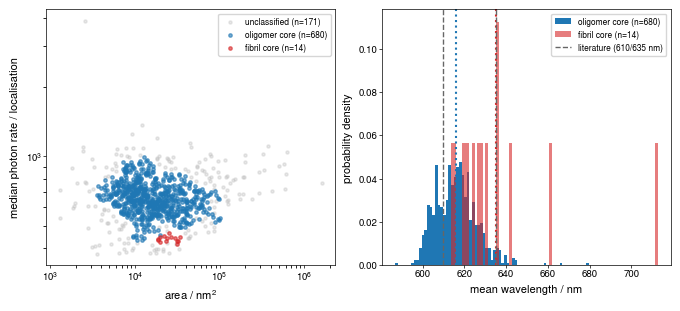

In [8]:
fig, axs = plotter.two_column_plot(nrows=1, ncols=2)

colours = {'oligomer': 'tab:blue', 'fibril': 'tab:red', 'noise': '0.75'}
labels_txt = {
    'oligomer': f'oligomer core (n={len(g0)})',
    'fibril':   f'fibril core (n={len(g1)})',
    'noise':    f'unclassified (n={len(g_noise)})',
}

ax = axs[0]
ax.scatter(g_noise['area_ellipse_nm2'], g_noise['median_photon_rate'], s=5, alpha=0.35,
           color=colours['noise'], label=labels_txt['noise'], zorder=1)
ax.scatter(g0['area_ellipse_nm2'], g0['median_photon_rate'], s=6, alpha=0.6,
           color=colours['oligomer'], label=labels_txt['oligomer'], zorder=2)
ax.scatter(g1['area_ellipse_nm2'], g1['median_photon_rate'], s=6, alpha=0.6,
           color=colours['fibril'], label=labels_txt['fibril'], zorder=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('area / nm$^2$', fontsize=8)
ax.set_ylabel('median photon rate / localisation', fontsize=8)
ax.legend(fontsize=6, loc='upper right')
ax.tick_params(labelsize=7)

ax = axs[1]
bins = np.linspace(min(g0.mean_wl.min(), g1.mean_wl.min()),
                    max(g0.mean_wl.max(), g1.mean_wl.max()), 100)
ax.hist(g0.mean_wl, bins=bins, alpha=1, color=colours['oligomer'], density=True, label=labels_txt['oligomer'])
ax.hist(g1.mean_wl, bins=bins, alpha=0.6, color=colours['fibril'], density=True, label=labels_txt['fibril'])
ax.axvline(g0.mean_wl.mean(), color=colours['oligomer'], ls=':', lw=1.5)
ax.axvline(g1.mean_wl.mean(), color=colours['fibril'], ls=':', lw=1.5)
ax.axvline(610, color='0.4', ls='--', lw=1, label='literature (610/635 nm)')
ax.axvline(635, color='0.4', ls='--', lw=1)
ax.set_xlabel('mean wavelength / nm', fontsize=8)
ax.set_ylabel('probability density', fontsize=8)
ax.legend(fontsize=6, loc='upper right')
ax.tick_params(labelsize=7)

plt.savefig(OUT_ROOT / "OligomerFibril_HDBSCAN_Wavelength.svg", bbox_inches='tight')
plt.show()